In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import time
from tqdm.auto import tqdm


In [2]:
# Transform (converts 3 channels and resizes)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

def get_dataloaders(dataset_name, batch_size, PinMem):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # Load the full combined pool to get an accurate 70-10-20 split
    if dataset_name == "MNIST":
        full_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        full_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Combine them to treat as one pool for the 70-10-20 split requirement
    complete_dataset = torch.utils.data.ConcatDataset([full_ds, test_ds])
    total_size = len(complete_dataset)

    # Calculate sizes based on percentages (70%, 10%, 20%)
    train_size = int(0.7 * total_size)
    val_size = int(0.1 * total_size)
    test_size = total_size - train_size - val_size

    # Perform the split
    train_ds, val_ds, test_ds = random_split(complete_dataset, [train_size, val_size, test_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=PinMem)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=PinMem)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=PinMem)

    return train_loader, val_loader, test_loader


In [3]:
def train_and_evaluate(dataset_name, device, bs, lr, epochs, pm, model_name):

    # Data Loaders
    train_loader, val_loader, test_loader = get_dataloaders(dataset_name, bs, pm)

    # Model Setup
    if model_name == "ResNet50":
        model = torchvision.models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 10)
        model.to(device)
    else:
        model = torchvision.models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 10)
        model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda')

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"{dataset_name} Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # Validation Phase
        val_loss, val_correct, val_total = 0, 0, 0
        model.eval()
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(train_loss/len(train_loader))
        history['val_loss'].append(val_loss/len(val_loader))
        history['train_acc'].append(100.*correct/total)
        history['val_acc'].append(100.*val_correct/val_total)

    return model, history, test_loader

In [4]:

def plot_metrics(history, dataset_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss Plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'{dataset_name} Loss')
    ax1.legend()

    # Accuracy Plot
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'{dataset_name} Accuracy')
    ax2.legend()
    plt.show()

def plot_confusion_matrix(model, test_loader, dataset_name, device):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {dataset_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 955kB/s]


MNIST Epoch 1:   0%|          | 0/3063 [00:00<?, ?it/s]

MNIST Epoch 2:   0%|          | 0/3063 [00:00<?, ?it/s]

MNIST Epoch 3:   0%|          | 0/3063 [00:00<?, ?it/s]

MNIST Epoch 4:   0%|          | 0/3063 [00:00<?, ?it/s]

MNIST Epoch 5:   0%|          | 0/3063 [00:00<?, ?it/s]

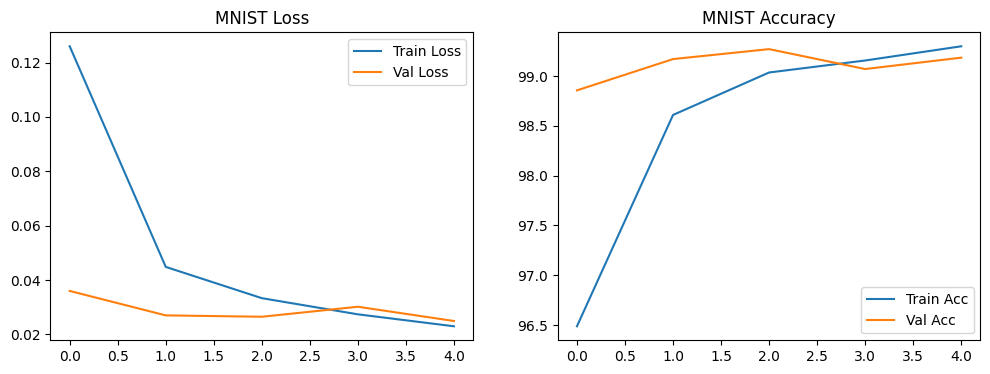

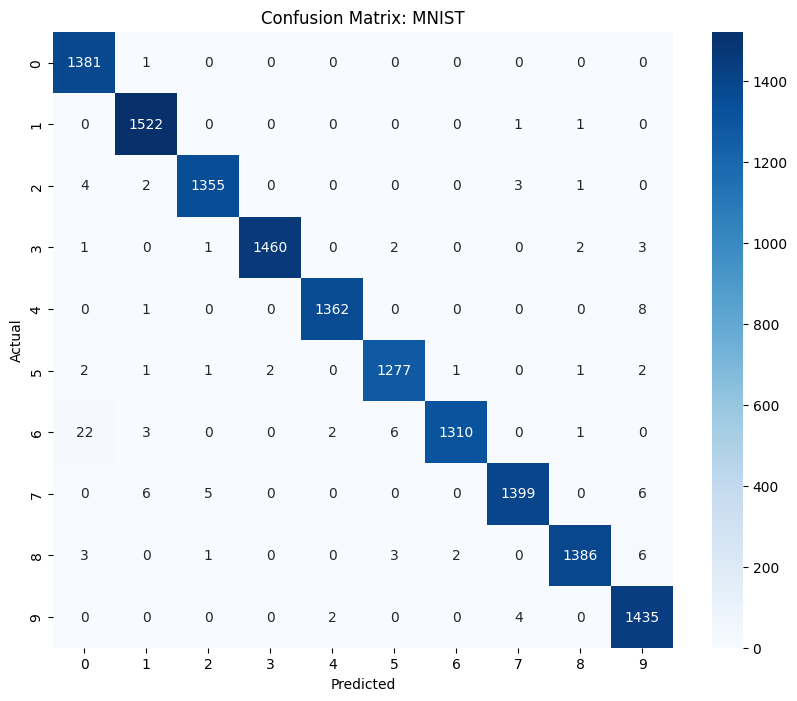

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

ds = "MNIST"
model, history, test_loader = train_and_evaluate(ds, device, 16, 0.0001, 5, True, "Resnet-18")

# Show Graphs
plot_metrics(history, ds)

# Show Confusion Matrix
plot_confusion_matrix(model, test_loader, ds, device)


FashionMNIST Epoch 1:   0%|          | 0/3063 [00:00<?, ?it/s]

FashionMNIST Epoch 2:   0%|          | 0/3063 [00:00<?, ?it/s]

FashionMNIST Epoch 3:   0%|          | 0/3063 [00:00<?, ?it/s]

FashionMNIST Epoch 4:   0%|          | 0/3063 [00:00<?, ?it/s]

FashionMNIST Epoch 5:   0%|          | 0/3063 [00:00<?, ?it/s]

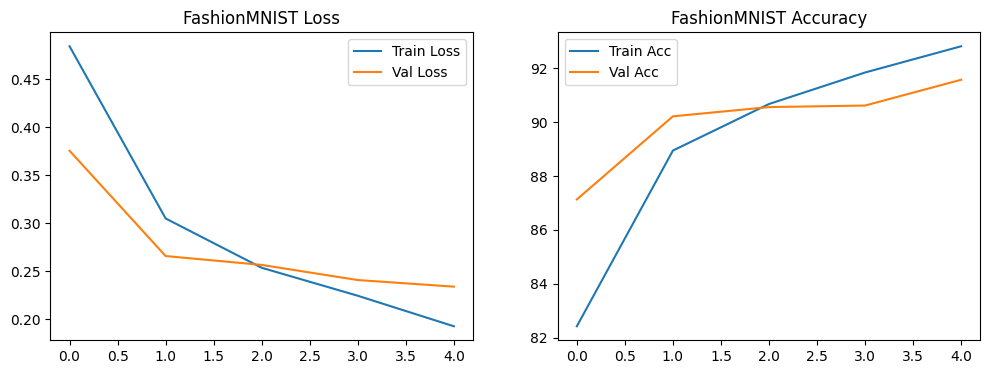

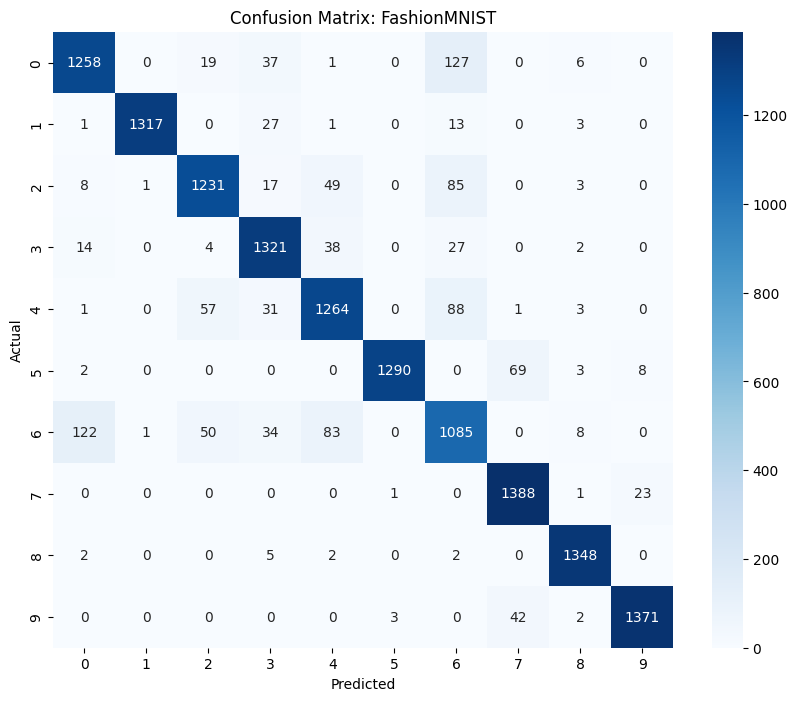

In [7]:
ds = "FashionMNIST"
model, history, test_loader = train_and_evaluate(ds, device, 16, 0.001, 5, False, "Resnet-18")

# Show Graphs
plot_metrics(history, ds)

# Show Confusion Matrix
plot_confusion_matrix(model, test_loader, ds, device)